# analysis_b / 03 — Latent Topic Discovery (LDA)

Unsupervised discovery of latent thematic structure in the corpus. No pre-imposed categories — topics are described purely from what emerges.

**Pipeline:** DTM → K selection (perplexity + PMI coherence) → fit final LDA → topic profiling (top words + top documents) → score/flair correlations

**Reads:** `artifacts/posts_clean.parquet`  
**Writes:** `artifacts/theta.npy`, `artifacts/phi.npy`, `artifacts/lda_vocab.json`, `artifacts/lda_model.pkl`, `artifacts/topic_labels.json`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import textwrap
import warnings
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from scipy.sparse import csc_matrix
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

ARTIFACTS = Path('artifacts')

df = pd.read_parquet(ARTIFACTS / 'posts_clean.parquet')
print(f'Posts: {len(df):,}')
df[['text_lemma', 'score', 'year_month', 'day_idx']].head(3)

Posts: 43,185


,text_lemma,score,year_month,day_idx
0,try post photo include keep say review end pos...,1,2025-05,129
1,kid 7/8year old play wood house potter happily...,1,2025-05,129
2,see beaver person shady gray ish rare capybara...,2,2025-05,129


## 1. Document-Term Matrix

In [2]:
vec = CountVectorizer(min_df=10, max_df=0.90)
dtm = vec.fit_transform(df['text_lemma'])
vocab = vec.get_feature_names_out()

print(f'DTM      : {dtm.shape[0]:,} docs × {dtm.shape[1]:,} terms')
print(f'Sparsity : {1 - dtm.nnz / (dtm.shape[0] * dtm.shape[1]):.2%}')

X_train, X_test = train_test_split(dtm, test_size=0.10, random_state=42)
print(f'Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}')

DTM      : 43,185 docs × 7,403 terms
Sparsity : 99.56%
Train: 38,866   Test: 4,319


## 2. K Selection

- **Perplexity** on held-out 10% — lower is better; tends to keep decreasing, so not sufficient alone
- **PMI coherence** — higher means more semantically coherent topics; choose K at the elbow

In [3]:
dtm_csc = csc_matrix((dtm > 0).astype(np.float32))

def pmi_coherence(topic_idx, phi, dtm_csc, n_top=10):
    top_w = phi[topic_idx].argsort()[::-1][:n_top]
    cols  = [
        np.asarray(dtm_csc.getcol(int(w)).todense()).flatten() > 0
        for w in top_w
    ]
    pmis = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            p_i  = cols[i].mean()
            p_j  = cols[j].mean()
            p_ij = (cols[i] & cols[j]).mean()
            if p_i > 0 and p_j > 0 and p_ij > 0:
                pmis.append(np.log(p_ij / (p_i * p_j)))
    return float(np.mean(pmis)) if pmis else 0.0

In [4]:
K_RANGE = [1,2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

for K in K_RANGE:
    lda_k = LatentDirichletAllocation(
        n_components=K, learning_method='online', max_iter=20, random_state=42
    )
    lda_k.fit(X_train)
    perp  = lda_k.perplexity(X_test)
    phi_k = lda_k.components_ / lda_k.components_.sum(axis=1, keepdims=True)
    coh   = float(np.mean([pmi_coherence(k, phi_k, dtm_csc) for k in range(K)]))
    results.append({'K': K, 'perplexity': perp, 'coherence': coh})
    print(f'K={K:2d}  perplexity={perp:9.1f}  coherence={coh:.4f}')

results_df = pd.DataFrame(results)

K= 1  perplexity=   1567.0  coherence=0.4082
K= 2  perplexity=   1549.6  coherence=0.4956
K= 3  perplexity=   1625.4  coherence=0.5347
K= 4  perplexity=   1705.0  coherence=0.5883
K= 5  perplexity=   1774.3  coherence=0.6021
K= 6  perplexity=   1843.1  coherence=0.6133
K= 7  perplexity=   1904.4  coherence=0.6347
K= 8  perplexity=   1951.0  coherence=0.6806
K= 9  perplexity=   2024.3  coherence=0.6044
K=10  perplexity=   2052.8  coherence=0.6747


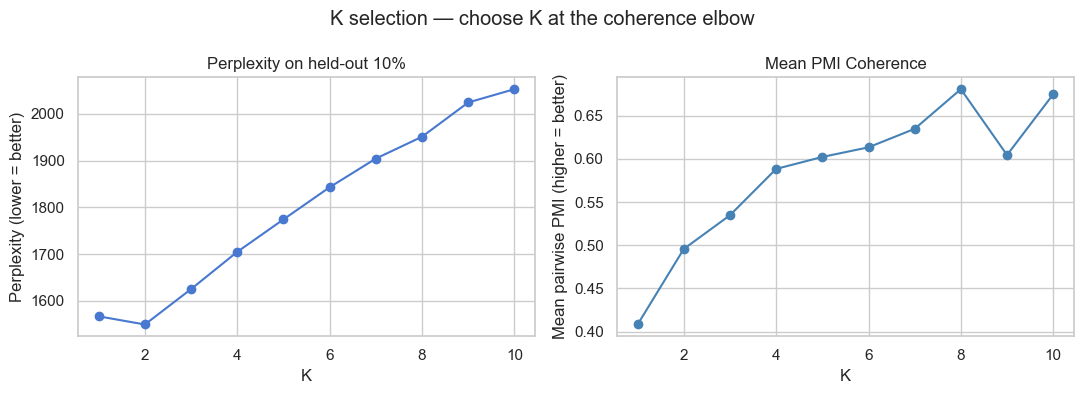

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(results_df['K'], results_df['perplexity'], marker='o')
ax1.set_title('Perplexity on held-out 10%')
ax1.set_xlabel('K')
ax1.set_ylabel('Perplexity (lower = better)')

ax2.plot(results_df['K'], results_df['coherence'], marker='o', color='steelblue')
ax2.set_title('Mean PMI Coherence')
ax2.set_xlabel('K')
ax2.set_ylabel('Mean pairwise PMI (higher = better)')

plt.suptitle('K selection — choose K at the coherence elbow')
plt.tight_layout()
plt.show()

## 3. Fit Final Model

Set `K_FINAL` based on the plot above.

In [6]:
K_FINAL = 4

lda = LatentDirichletAllocation(
    n_components=K_FINAL, learning_method='batch', max_iter=100, random_state=42
)
lda.fit(dtm)

print(f'Final model: K={K_FINAL}, held-out perplexity={lda.perplexity(X_test):.1f}')

Final model: K=4, held-out perplexity=1666.8


In [7]:
# phi   : (K, V) normalized topic-word matrix
# theta : (N, K) document-topic distribution
phi   = lda.components_ / lda.components_.sum(axis=1, keepdims=True)
theta = lda.transform(dtm)

print(f'phi   shape : {phi.shape}')
print(f'theta shape : {theta.shape}')
print(f'theta row-sum check (should be ~1.0): {theta.sum(axis=1).mean():.4f}')

phi   shape : (4, 7403)
theta shape : (43185, 4)
theta row-sum check (should be ~1.0): 1.0000


## 4. Topic Profiling

For each topic: top words + top 5 documents by theta loading. Read the documents — do not rely on words alone. Fill in the annotation table below.

In [8]:
N_TOP_WORDS = 20
vocab_list  = list(vocab)

print('Top words per topic')
print('=' * 70)
for k in range(K_FINAL):
    top_idx   = phi[k].argsort()[::-1][:N_TOP_WORDS]
    top_words = ', '.join(vocab_list[i] for i in top_idx)
    print(f'Topic {k:2d}: {top_words}')

Top words per topic
Topic  0: room, hear, house, night, see, sleep, feel, look, door, time, happen, bed, thing, think, get, light, wake, come, start, sound
Topic  1: tell, know, year, say, time, dream, see, day, think, get, old, friend, die, come, pass, happen, mom, feel, house, look
Topic  2: spirit, know, thing, feel, help, energy, people, good, try, want, demon, believe, life, entity, need, think, bad, way, come, love
Topic  3: people, experience, thing, paranormal, think, know, believe, ghost, time, happen, real, post, story, see, way, sound, find, look, try, brain


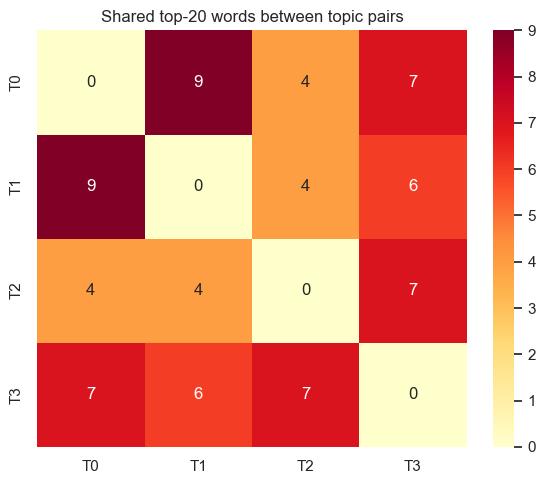


Shared words (top-20) per pair:
  T0 ∩ T1 (9): come, feel, get, happen, house, look, see, think, time
  T0 ∩ T2 (4): come, feel, thing, think
  T0 ∩ T3 (7): happen, look, see, sound, thing, think, time
  T1 ∩ T2 (4): come, feel, know, think
  T1 ∩ T3 (6): happen, know, look, see, think, time
  T2 ∩ T3 (7): believe, know, people, thing, think, try, way


In [9]:
import itertools

N_TOP = 20  # top words per topic to compare

# Get top-N word sets per topic
top_word_sets = {}
for k in range(K_FINAL):
    top_idx = phi[k].argsort()[::-1][:N_TOP]
    top_word_sets[k] = set(vocab_list[i] for i in top_idx)

# Pairwise overlap matrix
overlap = np.zeros((K_FINAL, K_FINAL), dtype=int)
for i, j in itertools.combinations(range(K_FINAL), 2):
    shared = top_word_sets[i] & top_word_sets[j]
    overlap[i, j] = len(shared)
    overlap[j, i] = len(shared)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    overlap, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=[f'T{k}' for k in range(K_FINAL)],
    yticklabels=[f'T{k}' for k in range(K_FINAL)],
    ax=ax
)
ax.set_title(f'Shared top-{N_TOP} words between topic pairs')
plt.tight_layout()
plt.show()

# Print which words are shared per pair
print(f'\nShared words (top-{N_TOP}) per pair:')
for i, j in itertools.combinations(range(K_FINAL), 2):
    shared = sorted(top_word_sets[i] & top_word_sets[j])
    print(f'  T{i} ∩ T{j} ({len(shared)}): {", ".join(shared) if shared else "none"}')


### FREX — Frequency × Exclusivity

Top words by raw probability alone are dominated by corpus-wide filler (*think*, *see*, *people*).
FREX re-ranks words by the harmonic mean of two ECDF-normalised scores:

- **Frequency** `phi[k, w]` — probability of the word within the topic  
- **Exclusivity** `phi[k, w] / Σ_k phi[k, w]` — share of the word's total mass in this topic

A word scores high only when it is *both* common in the topic *and* concentrated there.
`w` (default 0.5) trades off the two components.


In [10]:
from scipy.stats import rankdata

vocab_list = list(vocab) 

def frex(phi, w=0.5, n_top=15):
    """
    phi   : (K, V) row-normalised topic-word matrix
    w     : weight on frequency (1-w goes to exclusivity)
    returns frex_scores (K, V) and top word indices (K, n_top)
    """
    K, V = phi.shape

    # Exclusivity: fraction of word's total mass in each topic
    col_sums = phi.sum(axis=0)                          # (V,)
    excl = phi / np.where(col_sums > 0, col_sums, 1)   # (K, V)

    # ECDF-normalise within each topic (rank / V)
    freq_ecdf = np.apply_along_axis(
        lambda row: rankdata(row) / V, axis=1, arr=phi
    )
    excl_ecdf = np.apply_along_axis(
        lambda row: rankdata(row) / V, axis=1, arr=excl
    )

    # Harmonic mean of the two ECDF scores
    scores = 1.0 / (w / freq_ecdf + (1 - w) / excl_ecdf)

    top_idx = scores.argsort(axis=1)[:, ::-1][:, :n_top]
    return scores, top_idx


N_FREX   = 15
FREX_W   = 0.5   # 0.5 = balanced; closer to 1 = favour frequency

frex_scores, frex_top = frex(phi, w=FREX_W, n_top=N_FREX)

print(f'FREX top-{N_FREX} words per topic  (w={FREX_W})')
print('=' * 70)
for k in range(K_FINAL):
    words = ', '.join(vocab_list[i] for i in frex_top[k])
    print(f'Topic {k}: {words}')



FREX top-15 words per topic  (w=0.5)
Topic 0: room, door, bed, window, cat, bedroom, wall, asleep, floor, bathroom, corner, kitchen, awake, hallway, stair
Topic 1: road, hospital, aunt, father, grandfather, uncle, park, grandpa, cemetery, nurse, grandmother, cancer, truck, funeral, car
Topic 2: demon, spirit, soul, negative, prayer, sage, religion, priest, practice, energy, protection, salt, cleanse, harm, ritual
Topic 3: evidence, theory, prove, science, phenomenon, proof, alien, sub, medical, scientific, audio, investigation, symptom, capture, device


In [11]:
# --- side-by-side comparison: raw top-10 vs FREX top-10 ---
N_CMP = 10
cols = pd.MultiIndex.from_product(
    [[f'Topic {k}' for k in range(K_FINAL)], ['Raw', 'FREX']]
)
data = {}
for k in range(K_FINAL):
    raw_words  = [vocab_list[i] for i in phi[k].argsort()[::-1][:N_CMP]]
    frex_words = [vocab_list[i] for i in frex_top[k][:N_CMP]]
    data[(f'Topic {k}', 'Raw')]  = raw_words
    data[(f'Topic {k}', 'FREX')] = frex_words

cmp_df = pd.DataFrame(data, index=range(1, N_CMP + 1))
cmp_df.index.name = 'Rank'
cmp_df



Topic 0           Topic 1              Topic 2               Topic 3  \
         Raw      FREX     Raw         FREX     Raw      FREX         Raw   
Rank                                                                        
1       room      room    tell         road  spirit     demon      people   
2       hear      door    know     hospital    know    spirit  experience   
3      house       bed    year         aunt   thing      soul       thing   
4      night    window     say       father    feel  negative  paranormal   
5        see       cat    time  grandfather    help    prayer       think   
6      sleep   bedroom   dream        uncle  energy      sage        know   
7       feel      wall     see         park  people  religion     believe   
8       look    asleep     day      grandpa    good    priest       ghost   
9       door     floor   think     cemetery     try  practice        time   
10      time  bathroom     get        nurse    want    energy      happen   

                  
            FREX  
Rank              
1       evidence  
2         theory  
3          prove  
4        science  
5     phenomenon  
6          proof  
7          alien  
8            sub  
9        medical  
10    scientific

### Doc inspection

In [12]:
N_TOP_DOCS = 10

for k in range(K_FINAL):
    print('=' * 70)
    print(f'TOPIC {k} — top {N_TOP_DOCS} documents')
    print('=' * 70)
    top_doc_idx = theta[:, k].argsort()[::-1][:N_TOP_DOCS]
    for rank, idx in enumerate(top_doc_idx, start=1):
        row     = df.iloc[idx]
        loading = theta[idx, k]
        snippet = row['text_clean']
        date    = str(row.get('date', row.get('year_month', '')))
        print(f'  [{rank}] theta={loading:.3f} | {date}')
        print(textwrap.fill(snippet, width=76, initial_indent='      ', subsequent_indent='      '))
        print()
    print()

TOPIC 0 — top 10 documents
  [1] theta=0.999 | 2025-03-29 00:00:00
      In 4th grade to 7th, I lived in a three bedroom apartment with my mom
      and two sisters. My mom worked six to seven days a week. Nights on the
      weekend and depending on if Sunday was super busy at her weekend job
      she'd work then, but usually off on Sunday, and her full time job she
      would get home at 5:30-6, split on Fridays. So she never witnessed or
      believed me or my sister growing up. Anyways, the apartment was pretty
      haunted and reading some of these post reminded me of the pure fear I
      felt as a child, so I wanted to reminisce. I don't know if I was just
      an easy target because I would get so scared on top of being the
      youngest kid in the house, or if it was because I watched a lootttt of
      horror movies and shows and unintentionally did it to myself, being
      paranoid. For some reason, I was always scared of everything as a kid,
      this was before anx

In [13]:
N_TOP_DOCS = 10
md_path    = ARTIFACTS / 'top_docs.md'

lines = []
for k in range(K_FINAL):
    lines.append(f'# TOPIC {k} — top {N_TOP_DOCS} documents\n\n')
    top_doc_idx = theta[:, k].argsort()[::-1][:N_TOP_DOCS]
    for rank, idx in enumerate(top_doc_idx, start=1):
        row     = df.iloc[idx]
        loading = theta[idx, k]
        snippet = str(row['text_clean'])
        date    = str(row.get('date', row.get('year_month', '')))
        lines.append(f'- [{rank}] theta={loading:.3f} | {date}\n\n')
        wrapped = textwrap.fill(snippet, width=76,
                                initial_indent='  ',
                                subsequent_indent='  ')
        lines.append(f'{wrapped}\n\n')
    lines.append('\n---\n\n')

md_path.write_text(''.join(lines), encoding='utf-8')
print(f'Written → {md_path}')


Written → artifacts\top_docs.md


Topic 0: associated with health and mental health


In [14]:
N_SAMPLE    = 5
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

W = 82  # paragraph wrap width

dominant   = theta.argmax(axis=1)
is_post    = (df['type'] == 'post').values

for k in range(K_FINAL):
    print('\n' + '─' * W)
    print(f'  TOPIC {k} — {N_SAMPLE} sampled posts (dominant-member only)')
    print('─' * W)

    members    = np.where((dominant == k) & is_post)[0]
    sample_idx = rng.choice(members, size=min(N_SAMPLE, len(members)), replace=False)

    for rank, idx in enumerate(sample_idx, start=1):
        row     = df.iloc[idx]
        loading = theta[idx, k]
        date    = str(row.get('date', row.get('year_month', '')))

        print(f'\n  [{rank}]  {date}  |  score={row["score"]}  |  theta={loading:.3f}')
        print('  ' + '─' * (W - 2))

        paragraph = textwrap.fill(str(row['text_clean']), width=W - 4,
                                  initial_indent='  ',
                                  subsequent_indent='  ')
        print(paragraph)
        print()



──────────────────────────────────────────────────────────────────────────────────
  TOPIC 0 — 5 sampled posts (dominant-member only)
──────────────────────────────────────────────────────────────────────────────────

  [1]  2025-02-01 00:00:00  |  score=1  |  theta=0.805
  ────────────────────────────────────────────────────────────────────────────────
  First off, I’m asking for a friend. My friend and his partner just moved
  into a new apartment and signed a one year lease. Since they moved in, the
  partner started feeling a really threatening, dark energy in the apartment.
  She began to see a dark figure that she describes as an about 28 year-old
  man wearing black jeans. She can’t ever see his face. My friend didn’t
  believe her at first. Finally, when something ripped the blanket off them
  both at night they freaked out and he started to believe. He sees it now
  too. They hear things moving in the kitchen and around the house. They both
  now sense him around the house, b

## 5. Topic Distribution Heatmap

Mean theta per topic across the full corpus — shows which topics dominate overall.

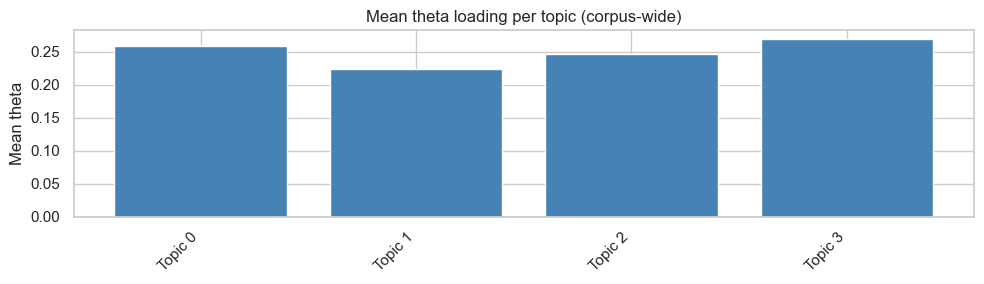

In [15]:
mean_theta = theta.mean(axis=0)
topic_labels_tmp = [f'Topic {k}' for k in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(K_FINAL), mean_theta, color='steelblue')
ax.set_xticks(range(K_FINAL))
ax.set_xticklabels(topic_labels_tmp, rotation=45, ha='right')
ax.set_title('Mean theta loading per topic (corpus-wide)')
ax.set_ylabel('Mean theta')
plt.tight_layout()
plt.show()

## 6. Score Correlation

Spearman rho between post score and each topic's theta loading. Reveals whether any topics attract more engagement. Bonferroni-corrected.

In [16]:
score_vals  = df['score'].fillna(0).values
alpha_bonf  = 0.05 / K_FINAL

print('Spearman rho: score ~ topic theta loading')
print(f'(* = Bonferroni-significant, threshold p < {alpha_bonf:.4f})')
print()
for k in range(K_FINAL):
    rho, p = spearmanr(score_vals, theta[:, k])
    sig    = '*' if p < alpha_bonf else ''
    print(f'  Topic {k:2d}: rho={rho:+.3f}  p={p:.4f}  {sig}')

Spearman rho: score ~ topic theta loading
(* = Bonferroni-significant, threshold p < 0.0125)

  Topic  0: rho=+0.017  p=0.0005  *
  Topic  1: rho=+0.121  p=0.0000  *
  Topic  2: rho=-0.076  p=0.0000  *
  Topic  3: rho=-0.061  p=0.0000  *


## 7. Write Artifacts

In [17]:
np.save(ARTIFACTS / 'theta.npy', theta)
np.save(ARTIFACTS / 'phi.npy',   phi)

with open(ARTIFACTS / 'lda_vocab.json', 'w') as fh:
    json.dump(list(vocab), fh)

joblib.dump(lda, ARTIFACTS / 'lda_model.pkl')

# Fill in labels before running 04_temporal.ipynb
template = {str(k): f'Topic {k} — label here' for k in range(K_FINAL)}
with open(ARTIFACTS / 'topic_labels.json', 'w') as fh:
    json.dump(template, fh, indent=2)

print('Artifacts written:')
for name in ('theta.npy', 'phi.npy', 'lda_vocab.json', 'lda_model.pkl', 'topic_labels.json'):
    p = ARTIFACTS / name
    if p.exists():
        print(f'  {p}  ({p.stat().st_size / 1024:.1f} KB)')

print()
print('Next: fill in topic_labels.json, then run 04_temporal.ipynb.')

Artifacts written:
  artifacts\theta.npy  (1349.7 KB)
  artifacts\phi.npy  (231.5 KB)
  artifacts\lda_vocab.json  (78.8 KB)
  artifacts\lda_model.pkl  (468.8 KB)
  artifacts\topic_labels.json  (0.1 KB)

Next: fill in topic_labels.json, then run 04_temporal.ipynb.


## Things worth knowing
